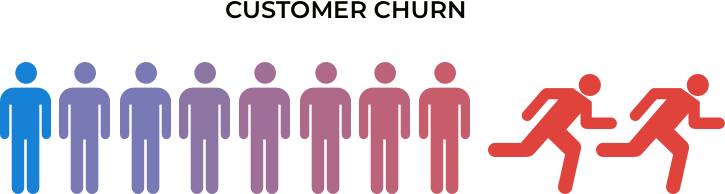

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries imported!')

Libraries imported!


In [10]:
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.info()
print("\n---\n")
print(df.describe())
# Fix error jo PDF me bataya hai
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("\nChurn Count:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


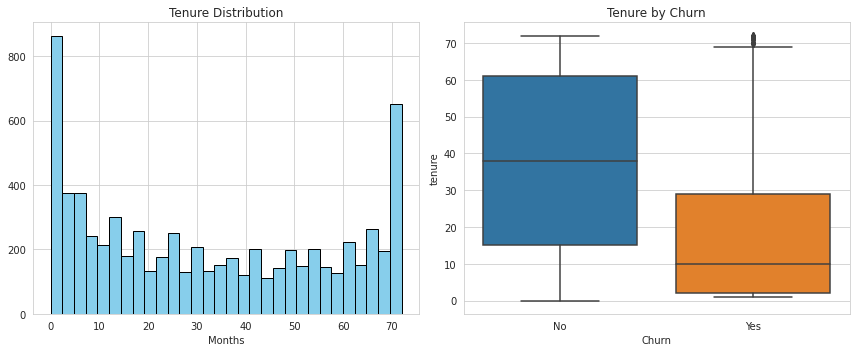

In [12]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
plt.title('Tenure Distribution')
plt.xlabel('Months')
plt.subplot(1,2,2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure by Churn')
plt.tight_layout()
plt.show()

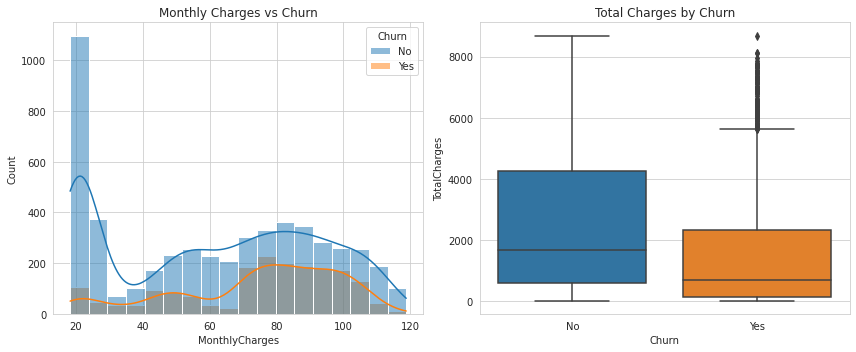

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.title('Monthly Charges vs Churn')
plt.subplot(1,2,2)
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title('Total Charges by Churn')
plt.tight_layout()
plt.show()

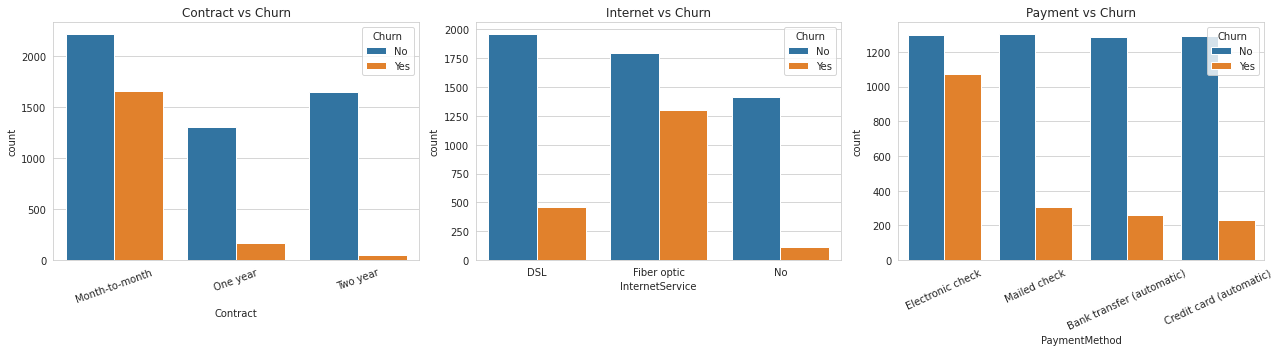

In [14]:
fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0])
axes[0].set_title('Contract vs Churn')
axes[0].tick_params(axis='x', rotation=20)
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[1])
axes[1].set_title('Internet vs Churn')
sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[2])
axes[2].set_title('Payment vs Churn')
axes[2].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

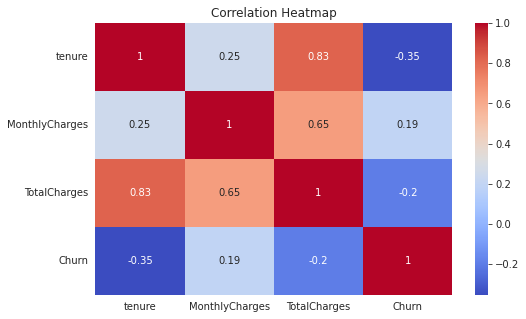

In [15]:
plt.figure(figsize=(8,5))
temp = df[['tenure','MonthlyCharges','TotalCharges']].copy()
temp['Churn'] = df['Churn'].apply(lambda x: 1 if x=='Yes' else 0)
sns.heatmap(temp.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Key Insights - Musa Khan - Oct 4, 2026
- Churn rate is 26.5% - 1 in 4 customers leave
- Month-to-month contract customers churn most
- New customers with 0-12 months tenure leave more
- Fiber optic and Electronic check users churn more
- High MonthlyCharges = higher churn